In [ ]:
import sympy
import numpy as np
from dms.robots import RR
from matplotlib import pyplot as plt
from dms.curves import cubic_interp

params={'L1':1,'L2':1.2}
robot=RR(params)


# Mover el robot
Sin perdida de generalizacion, podemos definir una tarea como mover el robot de un punto A a un punto.
Visualizamos donde comienza (A) y donde termina (B).

[36.15948764 68.6821381 ]


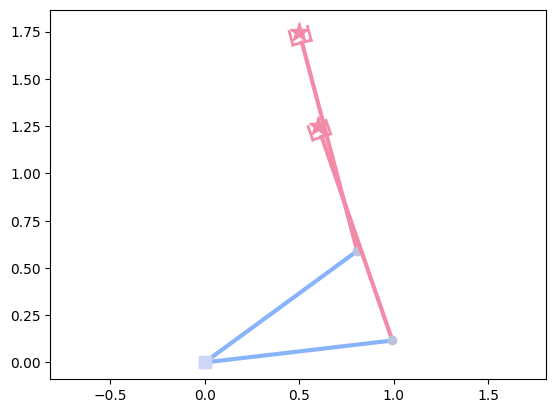

In [23]:
# Solucion cinematica inversa en caso A y B
pos_A=[0.5,1.75]
pos_B=[0.6,1.25]
theta0=[0.2,0.2]
resultA=robot.inverse_kinematics(*pos_A, theta0)
resultB=robot.inverse_kinematics(*pos_B, theta0)
plt.plot(*pos_A,'*b')
plt.plot(*pos_B,'*r')
plt.axis('equal')
robot.plot(resultA)
robot.plot(resultB)

print(np.rad2deg(resultA))

# Interpolacion en Joint space

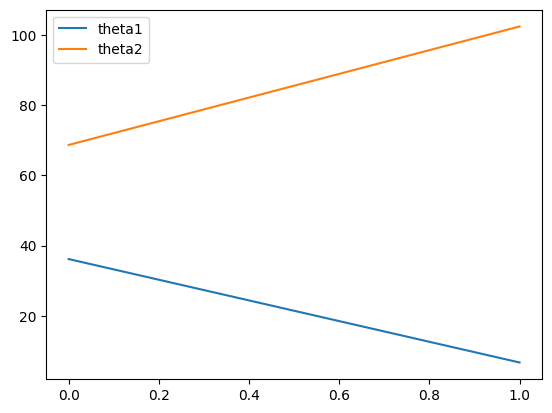

In [20]:
# Consideremos la interpolacion entre A y B
# Si fuera lineal que pasaria con el robot en el instante 0 y en el tiempo final?
plt.plot([0,1],np.rad2deg([resultA[0],resultB[0]]))
plt.plot([0,1],np.rad2deg([resultA[1],resultB[1]]))
plt.legend(['theta1','theta2'])
# Observe que la velocidad inicial y final no es cero. Si nuestro robot arranca
# y se detiene en A y B, entonces esta trayectoria no funciona.


# Interpolacion en cartesian space

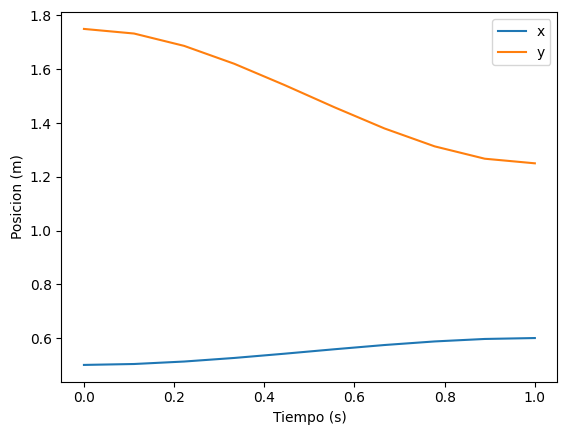

In [24]:
# Solucion cinematica en caso A y B
tt=np.linspace(0,1,10)
pos=cubic_interp(pos_A,np.zeros_like(pos_A),pos_B,np.zeros_like(pos_B))(tt)

plt.plot(tt,pos[:,0])
plt.plot(tt,pos[:,1])
plt.xlabel('Tiempo (s)')
plt.ylabel('Posicion (m)')
plt.legend(['x','y'])

(np.float64(-0.049660971892973395),
 np.float64(1.0428804097524413),
 np.float64(-0.0888653483974551),
 np.float64(1.866172316346557))

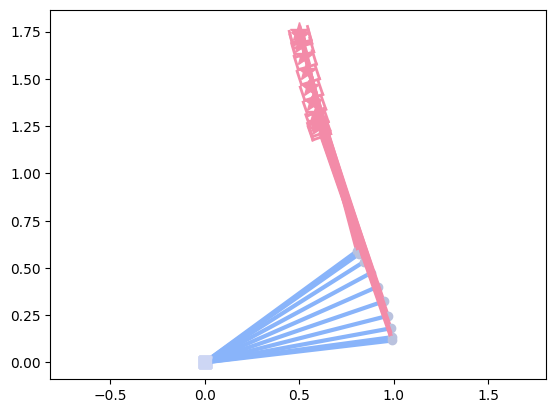

In [29]:
plt.plot(*pos_A,'*b')
plt.plot(*pos_B,'*r')
theta0=[0.2,0.2]
thetaList=[]
for i in range(len(tt)):
    result=robot.inverse_kinematics(pos[i,0],pos[i,1],theta0)        
    thetaList.append(result)
    robot.plot(result)
plt.axis('equal')



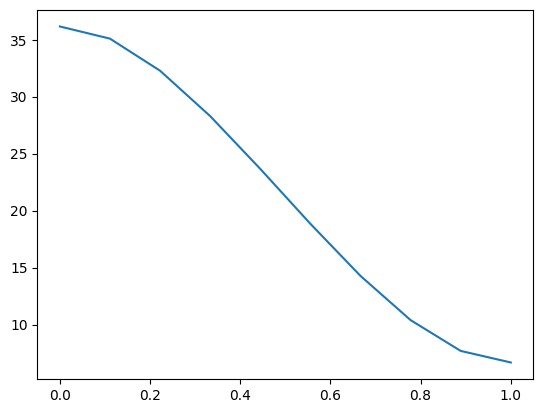

In [31]:





thetaList=np.array(thetaList)
plt.plot(tt,np.rad2deg(thetaList[:,0]))